# Decision Trees

# Entropy

In [1]:
#p1=0.5 and p2=0.5 
import math
entropy=-0.5*math.log2(0.5) -0.5*math.log2(0.5)
print("Entropy for 50%-50% case ==>", entropy)

Entropy for 50%-50% case ==> 1.0


In [2]:
entropy=-0.0001*math.log2(0.0001) -0.9999*math.log2(0.9999)
print("Entropy for 0%-100% case ==>", entropy)

Entropy for 0%-100% case ==> 0.0014730335283281598


In [3]:
import math
entropy=-0.45*math.log2(0.45) -0.55*math.log2(0.55)
print("Entropy for 45%-55% case ==>", entropy)

entropy=-0.05*math.log2(0.05) -0.95*math.log2(0.95)
print("Entropy for 5%-95% case ==>", entropy)

Entropy for 45%-55% case ==> 0.9927744539878083
Entropy for 5%-95% case ==> 0.28639695711595625


# Data Importing

In [4]:
"""
#To run in Google Colab
from google.colab import files
uploaded = files.upload()
"""

'\n#To run in Google Colab\nfrom google.colab import files\nuploaded = files.upload()\n'

In [5]:
"""
#Import / read the Dataset: Product_sales.csv

#Read the uploaded CSV file
import io
import pandas as pd # Import the pandas library and assign it the alias 'pd'

# Replace "Ecom_Cust_Survey_v1.csv" with the exact filename if different
Ecom_data = pd.read_csv(io.BytesIO(uploaded["Ecom_Cust_Survey_v1.csv"]))

# Preview the data
Ecom_data.head()
"""

'\n#Import / read the Dataset: Product_sales.csv\n\n#Read the uploaded CSV file\nimport io\nimport pandas as pd # Import the pandas library and assign it the alias \'pd\'\n\n# Replace "Ecom_Cust_Survey_v1.csv" with the exact filename if different\nEcom_data = pd.read_csv(io.BytesIO(uploaded["Ecom_Cust_Survey_v1.csv"]))\n\n# Preview the data\nEcom_data.head()\n'

In [6]:
#Import Data
import pandas as pd

Ecom_data = pd.read_csv("customer_survey.csv")

Ecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11805 entries, 0 to 11804
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Cust_num              11805 non-null  int64 
 1   Region                11805 non-null  int64 
 2   Age                   11805 non-null  int64 
 3   Order_Quantity        11805 non-null  int64 
 4   Customer_Type         11805 non-null  object
 5   Overall_Satisfaction  11805 non-null  object
dtypes: int64(4), object(2)
memory usage: 553.5+ KB


In [7]:
Ecom_data['Overall_Satisfaction'].value_counts()

Overall_Satisfaction
Dis Satisfied    6408
Satisfied        5397
Name: count, dtype: int64

# Convert Non-numerical Data into numerical

In [8]:
Ecom_data['Customer_Type_num'] = Ecom_data['Customer_Type'].map({'Prime': 1, 'Non_Prime': 0}).astype(int)
print(Ecom_data['Customer_Type'].value_counts())
print(Ecom_data['Customer_Type_num'].value_counts())

Customer_Type
Prime        6804
Non_Prime    5001
Name: count, dtype: int64
Customer_Type_num
1    6804
0    5001
Name: count, dtype: int64


In [ ]:
Ecom_data['Overall_Satisfaction_num'] = Ecom_data['Overall_Satisfaction'].map( {'Dis Satisfied': 0, 'Satisfied': 1} ).astype(int).astype(int)
print(Ecom_data['Overall_Satisfaction'].value_counts())   
print(Ecom_data['Overall_Satisfaction_num'].value_counts())

Overall_Satisfaction
Dis Satisfied    6408
Satisfied        5397
Name: count, dtype: int64
Overall_Satisfaction_num
0    6408
1    5397
Name: count, dtype: int64


In [10]:
Ecom_data.columns

Index(['Cust_num', 'Region', 'Age', 'Order_Quantity', 'Customer_Type',
       'Overall_Satisfaction', 'Customer_Type_num',
       'Overall_Satisfaction_num'],
      dtype='object')

# Decision Tree Model Building

In [11]:
from sklearn import tree

features= ['Region', 'Age', 'Order_Quantity',  'Customer_Type_num']
print("Features",features)

X = Ecom_data[features]
print("X shape", X.shape)
y = Ecom_data['Overall_Satisfaction']
print("Y shape", y.shape)

Features ['Region', 'Age', 'Order_Quantity', 'Customer_Type_num']
X shape (11805, 4)
Y shape (11805,)


|--- Order_Quantity <= 40.50
|   |--- Age <= 29.50
|   |   |--- class: Satisfied
|   |--- Age >  29.50
|   |   |--- class: Dis Satisfied
|--- Order_Quantity >  40.50
|   |--- Age <= 20.50
|   |   |--- class: Satisfied
|   |--- Age >  20.50
|   |   |--- class: Satisfied



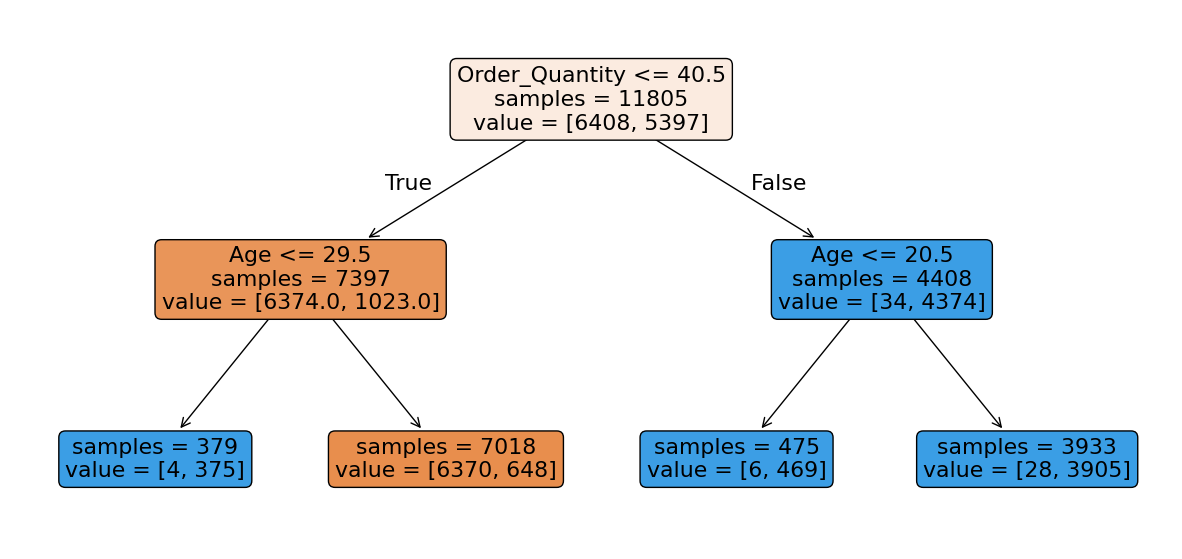

In [12]:
#Building Tree Model
DTree = tree.DecisionTreeClassifier(max_depth=2)
DTree.fit(X,y)

##Plotting the trees 
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
plt.figure(figsize=(15,7))
plot_tree(DTree, filled=True, 
                     rounded=True,
                     impurity=False,
                     feature_names = features)
print( export_text(DTree, feature_names = features))

In [13]:
#Check the Feature Importance

feature_importance = DTree.feature_importances_
for name, importance in zip(features, feature_importance):
    print(f"{name}: {importance:.4f}")


Region: 0.0000
Age: 0.1256
Order_Quantity: 0.8744
Customer_Type_num: 0.0000


# Tree Validation

In [14]:
##########Tree Validation
#Tree Validation
predict1 = DTree.predict(X)

from sklearn.metrics import confusion_matrix ###for using confusion matrix###
cm = confusion_matrix(y, predict1)
print (cm)

total = sum(sum(cm))
#####from confusion matrix calculate accuracy
accuracy = (cm[0,0]+cm[1,1])/total
print(accuracy)

[[6370   38]
 [ 648 4749]]
0.9418890300720034
